# Load & Inspect

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('../data/sql_imports/station_yearly_crimes.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   station         1000 non-null   object 
 1   years           1000 non-null   int64  
 2   longitude       1000 non-null   float64
 3   latitude        1000 non-null   float64
 4   total_crimes    1000 non-null   int64  
 5   murder          1000 non-null   int64  
 6   rape            1000 non-null   int64  
 7   robbery         1000 non-null   int64  
 8   assault_gbh     1000 non-null   int64  
 9   carjacking      1000 non-null   int64  
 10  property_crime  1000 non-null   int64  
 11  contact_crime   1000 non-null   int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 93.9+ KB


,years,longitude,latitude,total_crimes,murder,rape,robbery,assault_gbh,carjacking,property_crime,contact_crime
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2014.975000,26.319007,-29.376232,1744.892000,12.568000,29.112000,190.92000,127.83600,14.203000,802.918000,323.433000
std,4.317756,3.777875,3.295294,2137.190095,16.758587,32.777093,293.36491,138.29882,30.434455,1093.554979,365.883033
min,2008.000000,16.492180,-34.208600,1.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,2011.000000,24.525330,-32.790330,359.250000,2.000000,9.000000,15.00000,44.75000,0.000000,133.000000,101.000000
50%,2015.000000,27.359530,-29.134680,808.000000,6.000000,19.000000,50.00000,86.00000,1.000000,321.000000,203.500000
75%,2019.000000,28.680575,-26.260880,2253.000000,16.000000,38.000000,246.00000,157.00000,11.000000,959.500000,383.000000
max,2022.000000,31.082630,-22.682260,10528.000000,137.000000,226.000000,1636.00000,932.00000,201.000000,6713.000000,2650.000000


*Check for missing values*

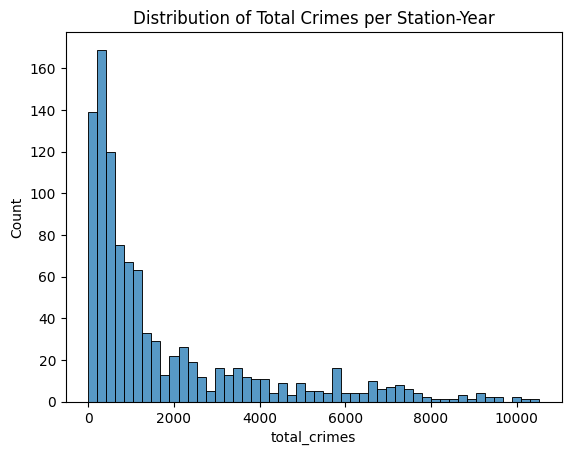

In [91]:
# Missing values 
df.isnull().sum()

# Plot distribution of target
sns.histplot(df['total_crimes'], bins=50)
plt.title('Distribution of Total Crimes per Station-Year')

plt.show()

## Feature Engineering

**1.1 Lag features (Temporal Memory)**

In [92]:
df = df.sort_values(['station', 'years'])
for col in ['total_crimes', 'murder', 'rape', 'robbery', 'assault_gbh', 'carjacking', 'property_crime', 'contact_crime']:
    df[f'{col}_lag1'] = df.groupby('station')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('station')[col].shift(2)
    df[f'{col}_lag3'] = df.groupby('station')[col].shift(3)


**1.2 Rolling Averages**

In [93]:
df['total_crimes_rolling3'] = df.groupby('station')['total_crimes'].transform(lambda x: x.rolling(3, min_periods=1).mean())

**1.3 Spartial Features**

In [94]:
from sklearn.cluster import KMeans
coords = df[['longitude', 'latitude']].dropna()
kmeans = KMeans(n_clusters=10, random_state=42)
df['spatial_cluster'] = kmeans.fit_predict(coords)


**1.4 Interaction & Derived Features**

In [95]:
df['prop_contact_ratio'] = df['property_crime_lag1'] / (df['contact_crime_lag1'] + 1)

**1.5 Drop NaN Rows (From Lags)**

In [96]:
df.dropna().reset_index(drop=True)

,station,years,longitude,latitude,total_crimes,murder,rape,robbery,assault_gbh,carjacking,...,carjacking_lag3,property_crime_lag1,property_crime_lag2,property_crime_lag3,contact_crime_lag1,contact_crime_lag2,contact_crime_lag3,total_crimes_rolling3,spatial_cluster,prop_contact_ratio
0,aberdeen,2011,24.06098,-32.47634,320,4,6,4,62,0,...,0.0,133.0,181.0,166.0,93.0,114.0,118.0,316.666667,7,1.414894
1,aberdeen,2012,24.06098,-32.47634,296,6,5,1,57,0,...,1.0,197.0,133.0,181.0,91.0,93.0,114.0,298.666667,7,2.141304
2,aberdeen,2013,24.06098,-32.47634,309,10,15,6,54,0,...,0.0,156.0,197.0,133.0,89.0,91.0,93.0,308.333333,7,1.733333
3,aberdeen,2014,24.06098,-32.47634,399,5,9,11,78,0,...,0.0,131.0,156.0,197.0,102.0,89.0,91.0,334.666667,7,1.271845
4,aberdeen,2015,24.06098,-32.47634,433,9,13,21,87,0,...,0.0,182.0,131.0,156.0,118.0,102.0,89.0,380.333333,7,1.529412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,berea,2013,31.00409,-29.84813,4114,2,6,342,36,34,...,69.0,2518.0,2823.0,2191.0,189.0,219.0,235.0,4013.666667,6,13.252632
795,berea,2014,31.00409,-29.84813,3559,2,8,336,26,28,...,64.0,2899.0,2518.0,2823.0,184.0,189.0,219.0,3845.333333,6,15.670270
796,berea,2015,31.00409,-29.84813,3261,3,8,383,30,41,...,47.0,2486.0,2899.0,2518.0,174.0,184.0,189.0,3644.666667,6,14.205714
797,berea,2016,31.00409,-29.84813,3702,8,8,616,24,129,...,34.0,2317.0,2486.0,2899.0,155.0,174.0,184.0,3507.333333,6,14.852564


## Train/Test Split (Time-Series Aware)

In [97]:
# Sort by year
df = df.sort_values('years')

# Train: 2008–2020, Test: 2021–2023
train_df = df[df['years'] <= 2020]
test_df = df[df['years'] >= 2021]

# Define features (exclude future values)
feature_cols = ['years', 'longitude', 'latitude', 'spatial_cluster',
                'total_crimes_lag1', 'total_crimes_lag2',
                'murder_lag1', 'rape_lag1', 'robbery_lag1',
                'assault_gbh_lag1', 'carjacking_lag1',
                'property_crime_lag1', 'contact_crime_lag1',
                'prop_contact_ratio']

X_train = train_df[feature_cols]
y_train = train_df['total_crimes']
X_test = test_df[feature_cols]
y_test = test_df['total_crimes']


## Model Training & Hyperparameter Tuning


**i. Random Forest**

In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, preds_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, preds_rf)))


RF MAE: 201.2613294903527
RF RMSE: 362.20995412682146


**ii. XGBoost (with Grid Search)**

In [99]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid = GridSearchCV(xgb_model, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_
preds_xgb = best_xgb.predict(X_test)


**iii. LightGBM**

In [100]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42, n_estimators=200, learning_rate=0.1)
lgb_model.fit(X_train, y_train)
preds_lgb = lgb_model.predict(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2123
[LightGBM] [Info] Number of data points in the train set: 868, number of used features: 14
[LightGBM] [Info] Start training from score 1784.122120


**iv. Ensemble**

In [101]:
preds_ensemble = (preds_rf + preds_xgb + preds_lgb) / 3

## Evaluation

In [102]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

evaluate(y_test, preds_rf, 'Random Forest')
evaluate(y_test, preds_xgb, 'XGBoost')
evaluate(y_test, preds_lgb, 'LightGBM')
evaluate(y_test, preds_ensemble, 'Ensemble')


Random Forest: MAE=201.26, RMSE=362.21, R²=0.956
XGBoost: MAE=280.24, RMSE=515.12, R²=0.911
LightGBM: MAE=267.97, RMSE=509.11, R²=0.913
Ensemble: MAE=243.02, RMSE=437.76, R²=0.936


## Visualise Predictions vs Actual

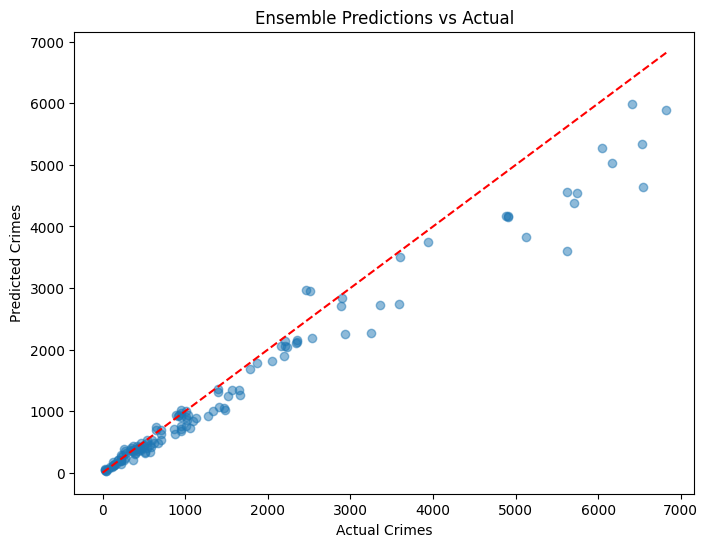

In [103]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, preds_ensemble, alpha=0.5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel('Actual Crimes')
plt.ylabel('Predicted Crimes')
plt.title('Ensemble Predictions vs Actual')
plt.show()


## Residual Analysis

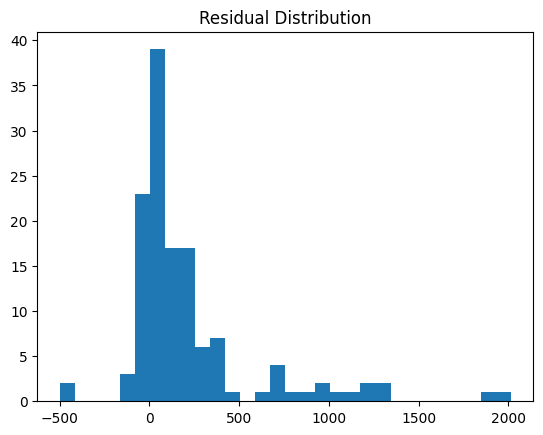

In [104]:
residuals = y_test - preds_ensemble
plt.hist(residuals, bins=30)
plt.title('Residual Distribution')
plt.show()


## Feature Importance

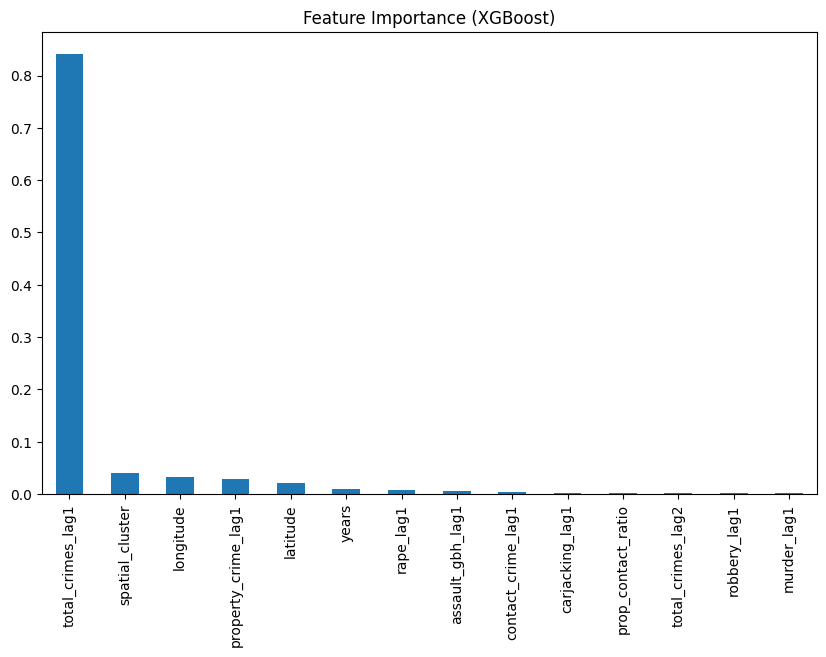

In [105]:
# XGBoost feature importance
importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(10,6))
plt.title('Feature Importance (XGBoost)')
plt.show()


## Save Predictions for Power BI

In [107]:
results = pd.DataFrame({
    'station': test_df['station'],
    'year': test_df['years'],
    'actual_crimes': y_test,
    'predicted_crimes': preds_ensemble,
    'error': np.abs(y_test - preds_ensemble)
})
results.to_csv('crime_predictions_2021_2023.csv', index=False)


In [108]:
df = pd.read_csv('crime_predictions_2021_2023.csv')
df.head()

,station,year,actual_crimes,predicted_crimes,error
0,atlantis,2021,5619,3605.002935,2013.997065
1,belhar,2021,647,739.704917,92.704917
2,alexandra,2021,6539,4640.106203,1898.893797
3,atamelang,2021,575,344.683668,230.316332
4,alexandra road,2021,3362,2718.811692,643.188308
